In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#loading csv file
dataji=pd.read_csv("C:\\Users\\Kartik\\Downloads\\Tech_Companies.csv")
dataji

,Company,Revenue ($B) USD[1],Profit ($B) USD[1],Employees[1],Country (origin),Headquarters
0,Amazon,$637.9,$59.2,"1,556,000",US,"Seattle, Washington & Arlington, Virginia, US"
1,Apple,$416.0,$112.0,"166,100",US,"Cupertino, California, US"
2,Alphabet,$350.0,$100.1,"190,167",US,"Mountain View, California, US"
3,Microsoft,$281.7,$101.8,"228,000",US,"Redmond, Washington, US"
4,Samsung Electronics,$220.3,$25.3,"270,372",South Korea,"Suwon, South Korea"
5,Foxconn,$213.9,$4.6,"767,062",Taiwan,"New Taipei City, Taiwan"
6,Meta,$164.5,$62.4,"78,450",US,"Menlo Park, California, US"
7,Jingdong,$158.8,$3.3,"620,000",China,"Beijing, China"
8,Alibaba,$137.3,$17.8,"124,320",China,"Hangzhou, China & George Town, Cayman Islands"
9,Nvidia,$130.5,$72.9,"36,000",US,"Sunnyvale, California, US"


In [3]:
#basic data description 
dataji.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Company              25 non-null     object
 1   Revenue ($B) USD[1]  25 non-null     object
 2   Profit ($B) USD[1]   25 non-null     object
 3   Employees[1]         25 non-null     object
 4   Country (origin)     25 non-null     object
 5   Headquarters         25 non-null     object
dtypes: object(6)
memory usage: 1.3+ KB


In [5]:
dataji.shape

(25, 6)

In [6]:
dataji.describe()

,Company,Revenue ($B) USD[1],Profit ($B) USD[1],Employees[1],Country (origin),Headquarters
count,25,25,25,25,25,25
unique,25,25,24,25,8,22
top,Amazon,$637.9,$4.6,"1,556,000",US,"Shenzhen, China"
freq,1,1,2,1,11,2


In [8]:
dataji.isnull().sum()

Company                0
Revenue ($B) USD[1]    0
Profit ($B) USD[1]     0
Employees[1]           0
Country (origin)       0
Headquarters           0
dtype: int64

In [11]:
dataji.duplicated().sum()

np.int64(0)

In [15]:
#correcting misformatted data 
dataji["Revenue ($B) USD[1]"]=(dataji["Revenue ($B) USD[1]"].replace(r'[\$,]', '', regex=True).astype(float))

In [16]:
dataji["Profit ($B) USD[1]"]=(dataji["Profit ($B) USD[1]"].replace(r'[\$,]', '', regex=True).astype(float))

In [18]:
dataji["Employees[1]"]=(dataji["Employees[1]"].replace(r'[,]', '', regex=True).astype(int))

Text(0.5, 1.0, 'Countries as origin of maximum companies')

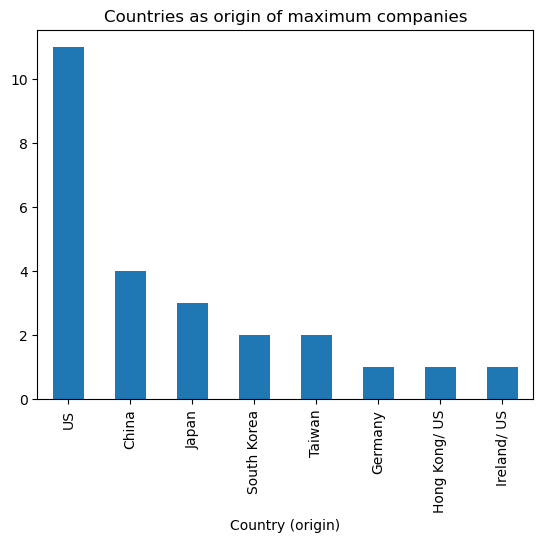

In [21]:
#Country-wise Distribution of Companies
dataji["Country (origin)"].value_counts().plot(kind="bar")
plt.title("Countries as origin of maximum companies")

Text(0, 0.5, 'Employees')

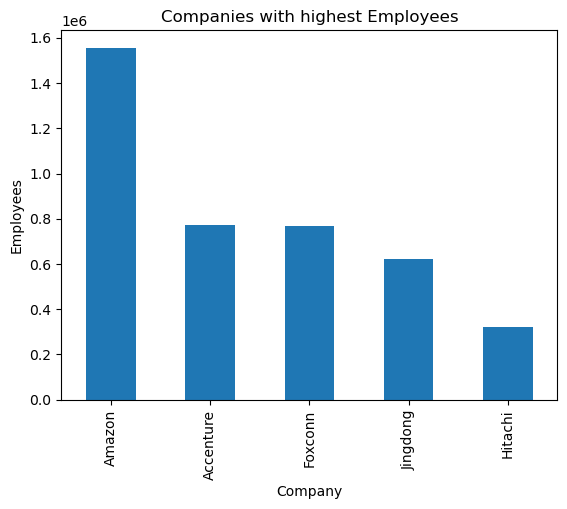

In [34]:
#Top 5 Companies by Employee Count
dataji.groupby("Company")["Employees[1]"].max().sort_values(ascending=False).head(5).plot(kind="bar")    
plt.title("Companies with highest Employees")
plt.ylabel("Employees")

Text(0, 0.5, 'REVENUE IN $B')

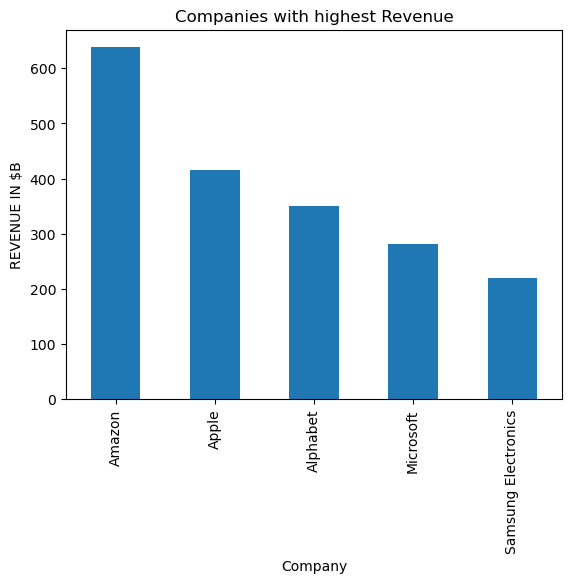

In [36]:
#Top 5 Companies by Revenue
dataji.groupby("Company")["Revenue ($B) USD[1]"].max().sort_values(ascending=False).head(5).plot(kind="bar")    
plt.title("Companies with highest Revenue")
plt.ylabel("REVENUE IN $B")

Text(0, 0.5, 'Profit IN $B')

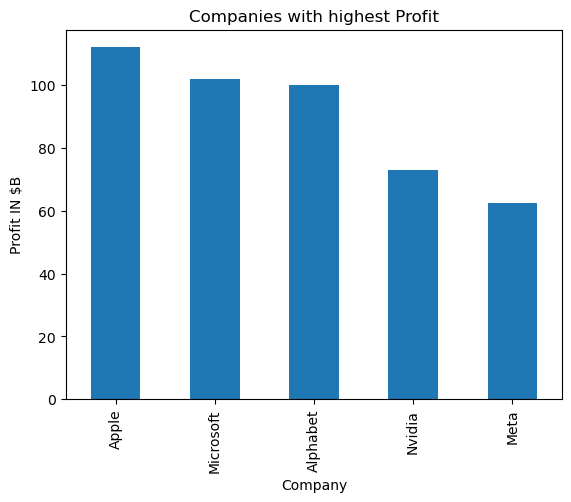

In [37]:
# Top 5 Companies by Profit
dataji.groupby("Company")["Profit ($B) USD[1]"].max().sort_values(ascending=False).head(5).plot(kind="bar")    
plt.title("Companies with highest Profit")
plt.ylabel("Profit IN $B")

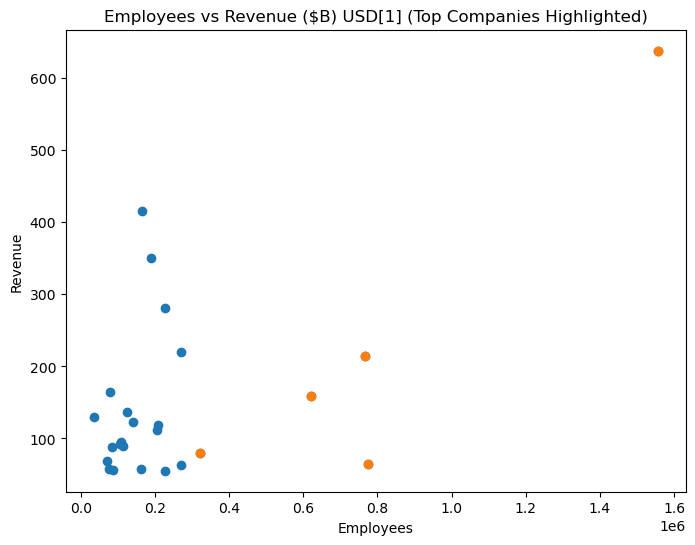

In [40]:
#Employees vs Revenue Analysis
top5 = dataji.sort_values(by='Employees[1]', ascending=False).head(5)

plt.figure(figsize=(8,6))
plt.scatter(dataji['Employees[1]'], dataji['Revenue ($B) USD[1]'])

# highlight top 5
plt.scatter(top5['Employees[1]'], top5['Revenue ($B) USD[1]'])

plt.title("Employees vs Revenue ($B) USD[1] (Top Companies Highlighted)")
plt.xlabel("Employees")
plt.ylabel("Revenue")

plt.show()

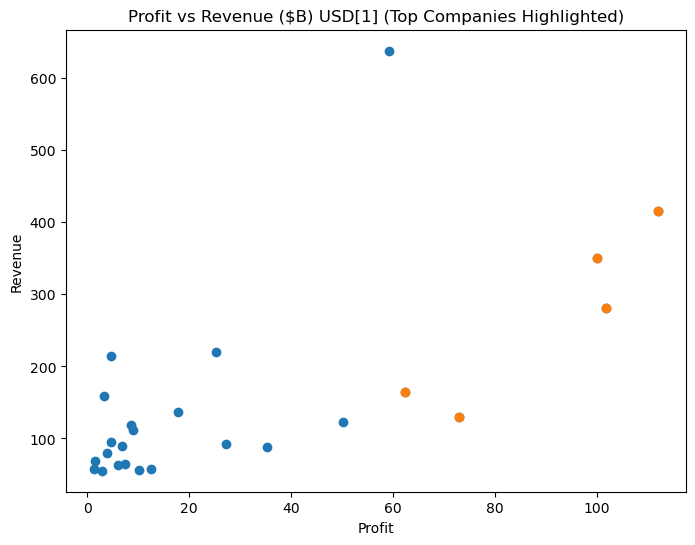

In [41]:
#Profit vs Revenue Analysis
top5 = dataji.sort_values(by='Profit ($B) USD[1]', ascending=False).head(5)

plt.figure(figsize=(8,6))
plt.scatter(dataji['Profit ($B) USD[1]'], dataji['Revenue ($B) USD[1]'])

# highlight top 5
plt.scatter(top5['Profit ($B) USD[1]'], top5['Revenue ($B) USD[1]'])

plt.title("Profit vs Revenue ($B) USD[1] (Top Companies Highlighted)")
plt.xlabel("Profit")
plt.ylabel("Revenue")

plt.show()

Text(0, 0.5, 'Companies')

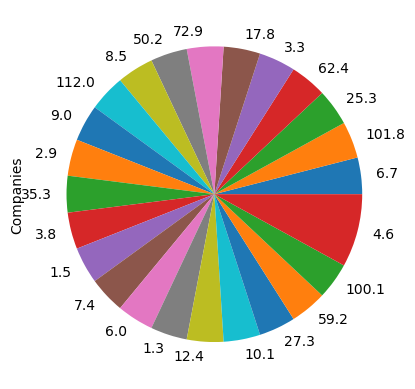

In [46]:
#Profit Distribution Analysis
dataji["Profit ($B) USD[1]"].value_counts().sort_values().plot(kind="pie")
plt.ylabel("Companies")

In [49]:
#Profit Margin Calculation
dataji['Profit_Margin'] = (dataji['Profit ($B) USD[1]'] / dataji['Revenue ($B) USD[1]']) * 100
top5_margin = dataji.sort_values(by='Profit_Margin', ascending=False).head(5)
top5_margin

,Company,Revenue ($B) USD[1],Profit ($B) USD[1],Employees[1],Country (origin),Headquarters,Profit_Margin
9,Nvidia,130.5,72.9,36000,US,"Sunnyvale, California, US",55.862069
10,AT&T,122.3,50.2,140990,US,"Dallas, Texas, US",41.046607
16,TSMC,88.3,35.3,83825,Taiwan,"New Taipei City, Taiwan",39.977350
6,Meta,164.5,62.4,78450,US,"Menlo Park, California, US",37.933131
3,Microsoft,281.7,101.8,228000,US,"Redmond, Washington, US",36.137735
